# Exploratory Data Analysis: Xente Transactions

Task 2 EDA for the Bati Bank credit risk project. This notebook explores the raw
Xente transaction dataset (`data/raw/data.csv`) to understand its structure, quality,
and the behavioral signals available for feature engineering and RFM-based proxy
target construction (Task 3 and Task 4).

This notebook is exploration only - reusable logic lives in `src/data_processing.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

DATA_PATH = Path("..") / "data" / "raw" / "data.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["TransactionStartTime"])
df.shape


(95662, 16)

## 1. Overview of the data

In [2]:
print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
df.info()


Rows: 95,662  Columns: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   TransactionId         95662 non-null  object             
 1   BatchId               95662 non-null  object             
 2   AccountId             95662 non-null  object             
 3   SubscriptionId        95662 non-null  object             
 4   CustomerId            95662 non-null  object             
 5   CurrencyCode          95662 non-null  object             
 6   CountryCode           95662 non-null  int64              
 7   ProviderId            95662 non-null  object             
 8   ProductId             95662 non-null  object             
 9   ProductCategory       95662 non-null  object             
 10  ChannelId             95662 non-null  object             
 11  Amount                95662 non-null  flo

In [3]:
df.head()


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


In [4]:
print("Unique customers:", df['CustomerId'].nunique())
print("Unique accounts:", df['AccountId'].nunique())
print("Date range:", df['TransactionStartTime'].min(), "->", df['TransactionStartTime'].max())
print("Span (days):", (df['TransactionStartTime'].max() - df['TransactionStartTime'].min()).days)


Unique customers: 3742
Unique accounts: 3633
Date range: 2018-11-15 02:18:49+00:00 -> 2019-02-13 10:01:28+00:00
Span (days): 90


## 2. Summary statistics

In [5]:
df.describe(include=[np.number]).T


,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


In [6]:
df.describe(include=["object"]).T


,count,unique,top,freq
TransactionId,95662,95662,TransactionId_76871,1
BatchId,95662,94809,BatchId_67019,28
AccountId,95662,3633,AccountId_4841,30893
SubscriptionId,95662,3627,SubscriptionId_3829,32630
CustomerId,95662,3742,CustomerId_7343,4091
CurrencyCode,95662,1,UGX,95662
ProviderId,95662,6,ProviderId_4,38189
ProductId,95662,23,ProductId_6,32635
ProductCategory,95662,9,financial_services,45405
ChannelId,95662,4,ChannelId_3,56935


## 3. Distribution of numerical features

`Amount` can be positive (debit) or negative (credit); `Value` is its absolute value.
`CountryCode` is investigated separately since a constant column carries no signal.

In [7]:
print("CountryCode unique values:", df['CountryCode'].unique())
print("CurrencyCode unique values:", df['CurrencyCode'].unique())
print("PricingStrategy unique values:", sorted(df['PricingStrategy'].unique()))


CountryCode unique values: [256]
CurrencyCode unique values: ['UGX']
PricingStrategy unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(4)]


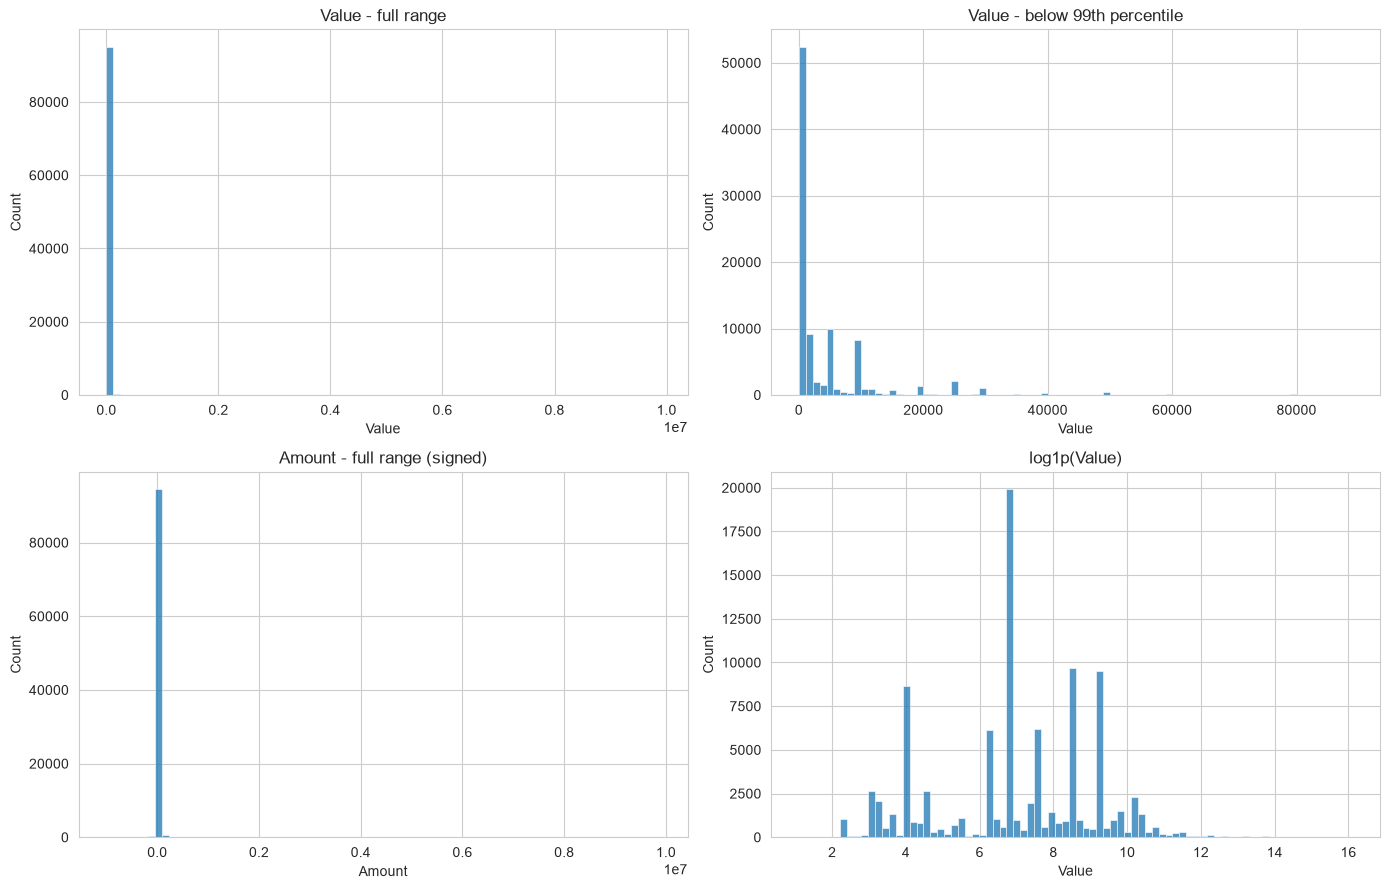

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df['Value'], bins=80, ax=axes[0, 0])
axes[0, 0].set_title("Value - full range")

sns.histplot(df[df['Value'] < df['Value'].quantile(0.99)]['Value'], bins=80, ax=axes[0, 1])
axes[0, 1].set_title("Value - below 99th percentile")

sns.histplot(df['Amount'], bins=80, ax=axes[1, 0])
axes[1, 0].set_title("Amount - full range (signed)")

sns.histplot(np.log1p(df['Value']), bins=80, ax=axes[1, 1])
axes[1, 1].set_title("log1p(Value)")

plt.tight_layout()
plt.savefig("../reports/figures/eda_numerical_distributions.png", dpi=120)
plt.show()


In [9]:
skew_kurt = pd.DataFrame({
    "skew": [df['Amount'].skew(), df['Value'].skew()],
    "kurtosis": [df['Amount'].kurtosis(), df['Value'].kurtosis()],
}, index=["Amount", "Value"])
skew_kurt


,skew,kurtosis
Amount,51.098490,3363.127739
Value,51.291086,3378.069274


In [10]:
print("Share of debit transactions (Amount > 0):", (df['Amount'] > 0).mean().round(4))
print("Share of credit transactions (Amount < 0):", (df['Amount'] < 0).mean().round(4))
print("Share of zero-amount transactions:", (df['Amount'] == 0).mean().round(4))


Share of debit transactions (Amount > 0): 0.6008
Share of credit transactions (Amount < 0): 0.3992
Share of zero-amount transactions: 0.0


## 4. Distribution of categorical features

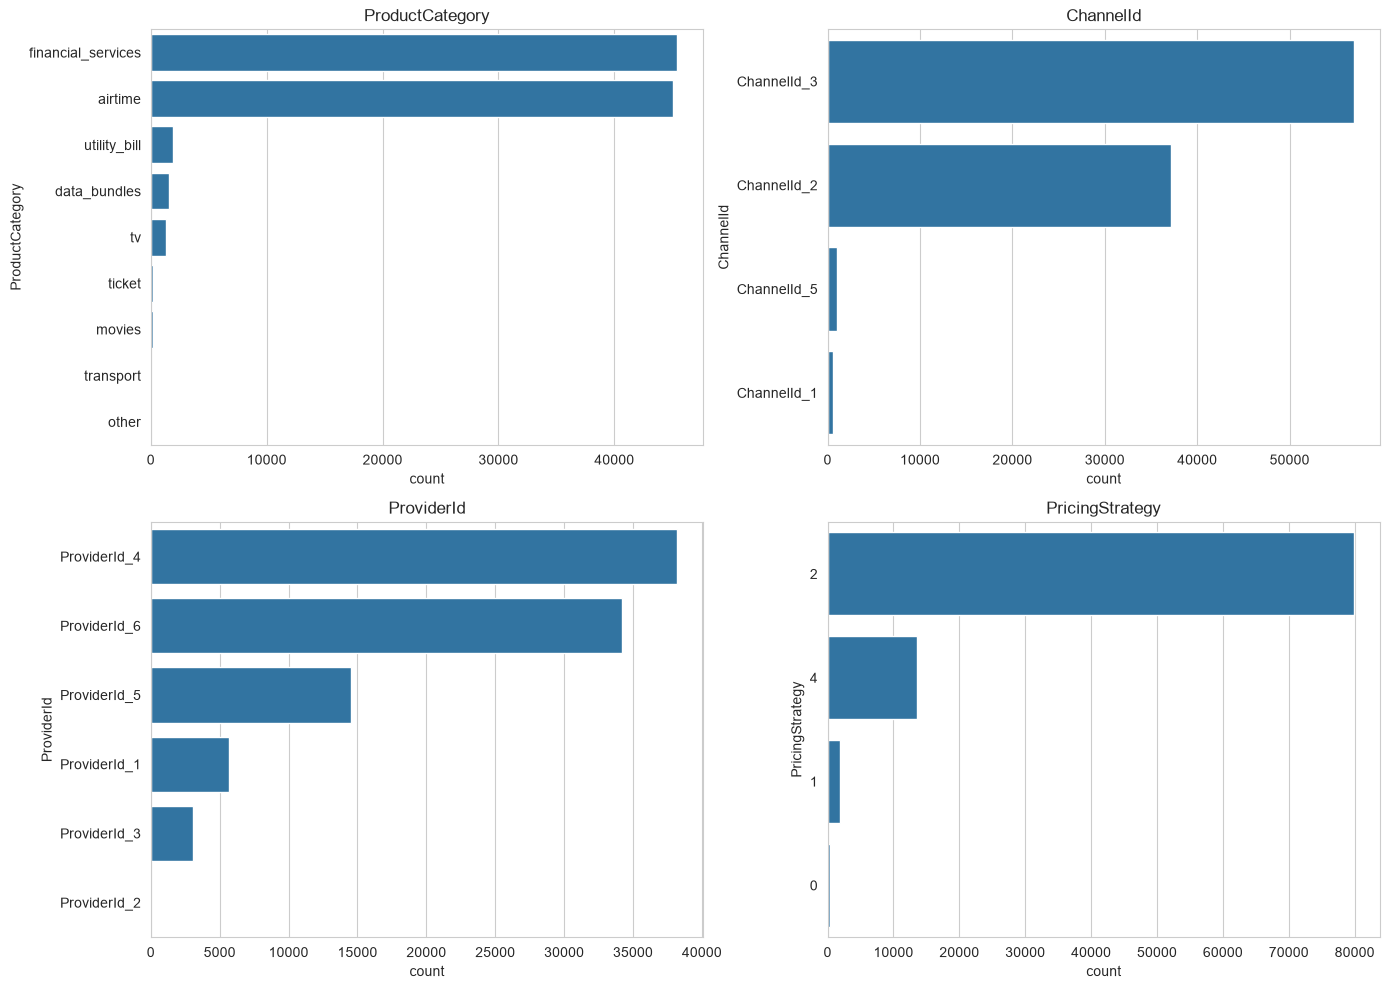

In [11]:
cat_cols = ["ProductCategory", "ChannelId", "ProviderId", "PricingStrategy"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].astype(str).value_counts().index
    sns.countplot(y=df[col].astype(str), order=order, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../reports/figures/eda_categorical_distributions.png", dpi=120)
plt.show()


In [12]:
print("ProductCategory value counts:")
print(df['ProductCategory'].value_counts())
print()
print("ChannelId value counts:")
print(df['ChannelId'].value_counts())


ProductCategory value counts:
ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

ChannelId value counts:
ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64


In [13]:
print("FraudResult distribution:")
print(df['FraudResult'].value_counts())
print("Fraud rate:", df['FraudResult'].mean().round(5))


FraudResult distribution:
FraudResult
0    95469
1      193
Name: count, dtype: int64
Fraud rate: 0.00202


## 5. Correlation analysis (numerical features)

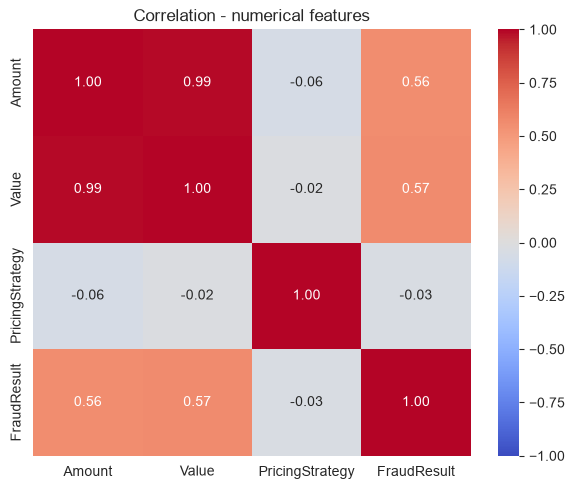

In [14]:
num_cols = ["Amount", "Value", "PricingStrategy", "FraudResult"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation - numerical features")
plt.tight_layout()
plt.savefig("../reports/figures/eda_correlation_heatmap.png", dpi=120)
plt.show()


`Value` and `Amount` are near-perfectly correlated (Value is the absolute value of
Amount), which is expected and means one is largely redundant once transaction
direction is captured separately (e.g. via a debit/credit indicator).

## 6. Missing values

In [15]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(3)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
TransactionId,0,0.0
BatchId,0,0.0
AccountId,0,0.0
SubscriptionId,0,0.0
CustomerId,0,0.0
CurrencyCode,0,0.0
CountryCode,0,0.0
ProviderId,0,0.0
ProductId,0,0.0
ProductCategory,0,0.0


## 7. Outlier detection

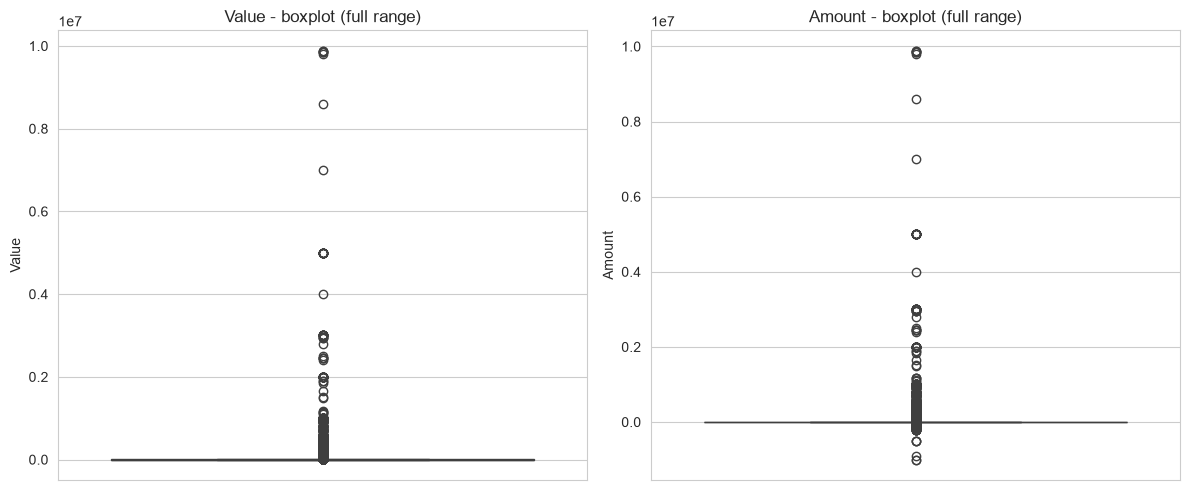

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Value'], ax=axes[0])
axes[0].set_title("Value - boxplot (full range)")
sns.boxplot(y=df['Amount'], ax=axes[1])
axes[1].set_title("Amount - boxplot (full range)")
plt.tight_layout()
plt.savefig("../reports/figures/eda_outlier_boxplots.png", dpi=120)
plt.show()


In [17]:
q1, q3 = df['Value'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outliers = df[df['Value'] > upper_fence]
print(f"IQR outlier fence (Value): {upper_fence:,.2f}")
print(f"Transactions above fence: {len(outliers):,} ({len(outliers)/len(df):.2%})")
print(f"Unique customers affected: {outliers['CustomerId'].nunique():,}")
outliers['Value'].describe()


IQR outlier fence (Value): 12,087.50
Transactions above fence: 9,021 (9.43%)
Unique customers affected: 1,157


count    9.021000e+03
mean     8.098319e+04
std      3.938119e+05
min      1.230000e+04
25%      2.000000e+04
50%      2.500000e+04
75%      4.000000e+04
max      9.880000e+06
Name: Value, dtype: float64

## 8. Customer-level transaction counts

Credit decisions are made at the customer level, but the raw data is transaction-level.
This checks how much history is typically available per customer, which matters for
RFM reliability (Task 4).

In [18]:
txn_per_customer = df.groupby('CustomerId').size()
txn_per_customer.describe()


count    3742.000000
mean       25.564404
std        96.929602
min         1.000000
25%         2.000000
50%         7.000000
75%        20.000000
max      4091.000000
dtype: float64

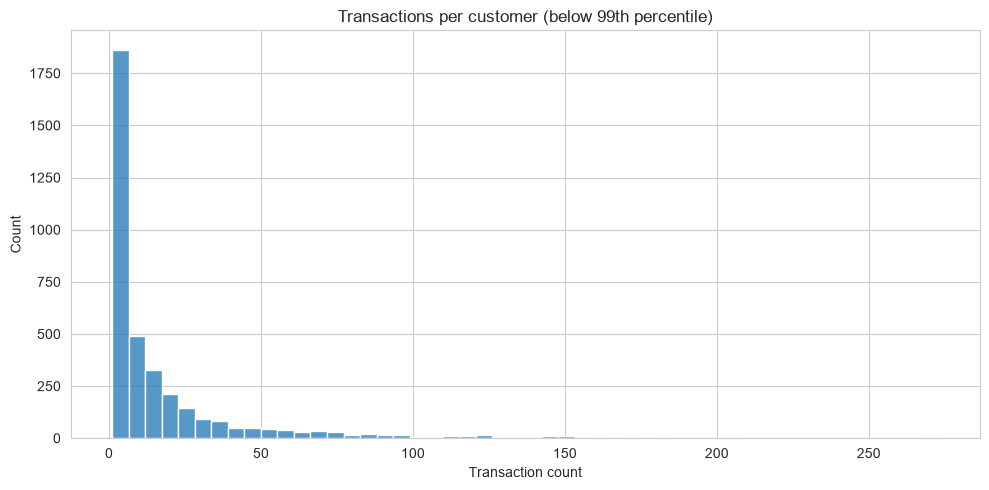

Customers with only 1 transaction: 712 (19.0%)


In [19]:
fig, ax = plt.subplots()
sns.histplot(txn_per_customer[txn_per_customer < txn_per_customer.quantile(0.99)], bins=50, ax=ax)
ax.set_title("Transactions per customer (below 99th percentile)")
ax.set_xlabel("Transaction count")
plt.tight_layout()
plt.savefig("../reports/figures/eda_transactions_per_customer.png", dpi=120)
plt.show()
print("Customers with only 1 transaction:", (txn_per_customer == 1).sum(),
      f"({(txn_per_customer == 1).mean():.1%})")


## Top insights

1. **The dataset is transaction-level (95,662 rows) and customer-level credit
   decisions require aggregation to only 3,742 unique customers** (mean 25.6
   transactions/customer, but median just 7 and 19.0% of customers (712) have only
   a single transaction). Frequency/monetary signal is unreliable for the ~1-in-5
   single-transaction customers, which is a direct risk to the RFM-based proxy
   target in Task 4: sparse history should not be conflated with genuine
   disengagement.
2. **`Amount`/`Value` are extremely right-skewed with heavy outliers** (skew ~51,
   kurtosis ~3,363 for both). 9.43% of transactions (9,021, affecting 1,157
   customers) sit above the IQR outlier fence. Aggregates like mean/total will be
   pulled by a few large transactions, so median, count, and standard deviation
   should accompany any total/average feature, and RFM's monetary component should
   be scaled (not raw) before K-Means clustering.
3. **`CountryCode` (always 256) and `CurrencyCode` (always UGX) are constant columns**
   and carry zero predictive signal for this dataset slice - they should be dropped
   from modeling features rather than one-hot encoded.
4. **`FraudResult` is extremely imbalanced (0.202% positive, 193 of 95,662) and is a
   distinct risk event from credit default.** It is not usable as, or a substitute
   for, the credit risk target; it may only be useful as an auxiliary behavioral
   feature.
5. **`Value` and `Amount` are almost perfectly correlated** (Value = abs(Amount)), so
   using both as independent numerical features would be redundant - a debit/credit
   direction indicator (60.1% debits, 39.9% credits, 0% zero-amount) plus `Value`
   captures the same information more efficiently.
6. **No missing values were found in any column** of the raw dataset, which
   simplifies Task 3: the pipeline still needs an imputer for robustness against
   future data drift, but no rows/columns need to be dropped for missingness here.
7. **Two product categories (`financial_services`, `airtime`) account for ~94.5% of
   all transactions**, and two channels (`ChannelId_2`, `ChannelId_3`) account for
   ~98.4% of transactions - category/channel diversity per customer is a plausible
   engineered feature, but rare categories will need care (e.g. grouping) to avoid
   sparse one-hot columns.